# Transit Induced Gentrification: Predicting the Impact of the LA 2028 Olympics D Line Extension

## Research Question
How will the construction of the D Line (Purple) Extension to Westwood/UCLA for the 2028 LA Olympics drive gentrification in surrounding neighborhoods?

## Literature Foundation
| Component | Source |
|---|---|
| Rent Premium (RP) | Zuk et al. (2018) *J. Planning Literature* |
| Rent Burden (RB) | HUD 30% rule; Zuk et al. (2018) |
| Rent Appreciation (SRA) | Chapple & Zuk (2016) *Cityscape* |
| Price/SqFt Premium (PSP) | Chapple & Zuk (2016) |
| Education Change (EDC) | Freeman (2005) *Urban Affairs Review* |
| 0.5-mile TOD buffer | Kahn (2007) *Real Estate Economics* |
| Distance-decay curve | Nilsson & Delmelle (2018) *J. Transport Geography* |

In [1]:
import os, warnings, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor

In [2]:
PROJECT_DIR = Path('/Users/chon/Desktop/academics/STAT_405/STAT-405-Project')
ENV_FILE    = Path('/Users/chon/Desktop/academics/STAT_405/STAT-405-Project/.env')
HOUSING_CSV = PROJECT_DIR / 'housing_combined_data_geocoded.csv'
METRO_CSV   = PROJECT_DIR / 'MetroLines_with_Lines.csv'
CHARTS_DIR  = PROJECT_DIR / 'Charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(ENV_FILE)
CENSUS_KEY = os.getenv('CENSUS_API_KEY')
print(f"Census API key: {'key loaded' if CENSUS_KEY else 'no key loaded — check .env'}")
print(f"Charts dir    : {CHARTS_DIR}")


Census API key: key loaded
Charts dir    : /Users/chon/Desktop/academics/STAT_405/STAT-405-Project/Charts


## Census API Enrichment
Pull ACS 5-year estimates (2019 and 2024) at the ZIP Code Tabulation Area (ZCTA) level for California.
Variables: median gross rent, median household income, educational attainment, poverty status.


In [3]:
# ACS variable codes (https://api.census.gov/data/2019/acs/acs5/variables.html)
CENSUS_VARS = ','.join([
    'B25064_001E',   # median gross rent
    'B19013_001E',   # median household income
    'B15003_001E',   # population 25+ (education denominator)
    'B15003_022E',   # bachelor's degree
    'B15003_023E',   # master's degree
    'B15003_024E',   # professional school degree
    'B15003_025E',   # doctorate
    'B17001_001E',   # total for poverty determination
    'B17001_002E',   # below poverty level
])

RENAME_MAP = {
    'zip code tabulation area': 'zcta',
    'B25064_001E': 'median_rent',
    'B19013_001E': 'median_income',
    'B15003_001E': 'pop25_total',
    'B15003_022E': 'bachelors',
    'B15003_023E': 'masters',
    'B15003_024E': 'professional',
    'B15003_025E': 'doctorate',
    'B17001_001E': 'pov_total',
    'B17001_002E': 'pov_below',
}

# Build target ZIP set from housing data plus Olympics corridor ZIPs
_target_zips = set(
    pd.read_csv(HOUSING_CSV, usecols=['Zip'], dtype=str)['Zip']
    .str.strip().str.zfill(5).dropna().tolist()
)
_target_zips.update(['90024', '90025', '90049', '90035', '90048', '90210'])
print(f"Target ZIPs: {len(_target_zips)}")

def fetch_acs(year, key, target_zips):
    # ACS 2024+ does not support state-level filtering for ZCTAs — use national wildcard
    if year >= 2024:
        url = (
            f"https://api.census.gov/data/{year}/acs/acs5"
            f"?get=NAME,{CENSUS_VARS}"
            f"&for=zip%20code%20tabulation%20area:*"
            f"&key={key}"
        )
        r = requests.get(url, timeout=180)
        r.raise_for_status()
        data = r.json()
        df = pd.DataFrame(data[1:], columns=data[0])
    else:
        # For 2019, batch requests by ZIP to stay within timeout limits
        zcta_list = sorted(target_zips)
        frames, batch_size = [], 50
        n_batches = -(-len(zcta_list) // batch_size)
        for i in range(0, len(zcta_list), batch_size):
            batch = ','.join(zcta_list[i:i + batch_size])
            url = (
                f"https://api.census.gov/data/{year}/acs/acs5"
                f"?get=NAME,{CENSUS_VARS}"
                f"&for=zip%20code%20tabulation%20area:{batch}"
                f"&in=state:06"
                f"&key={key}"
            )
            r = requests.get(url, timeout=120)
            if r.status_code != 200 or not r.text.strip().startswith('['):
                continue
            data = r.json()
            frames.append(pd.DataFrame(data[1:], columns=data[0]))
            print(f"  batch {i//batch_size+1}/{n_batches}", end='\r')
        df = pd.concat(frames, ignore_index=True)

    df = df.rename(columns=RENAME_MAP)
    num_cols = [c for c in df.columns if c not in ('NAME', 'zcta', 'state')]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
    df[num_cols] = df[num_cols].where(df[num_cols] > -1_000_000, np.nan)
    df = df[df['zcta'].isin(target_zips)].copy()
    return df[['zcta'] + num_cols]

print("Fetching ACS 2019")
acs_2019 = fetch_acs(2019, CENSUS_KEY, _target_zips)
print(f"{len(acs_2019):,} ZCTAs")

print("Fetching ACS 2024")
acs_2024 = fetch_acs(2024, CENSUS_KEY, _target_zips)
print(f"{len(acs_2024):,} ZCTAs")

acs_2019_s = acs_2019.rename(columns={c: f'{c}_2019' for c in acs_2019.columns if c != 'zcta'})
acs_2024_s = acs_2024.rename(columns={c: f'{c}_2024' for c in acs_2024.columns if c != 'zcta'})
acs = acs_2024_s.merge(acs_2019_s, on='zcta', how='left')

def pct_bachelor(df, yr):
    num = (df[f'bachelors_{yr}'] + df[f'masters_{yr}'] +
           df[f'professional_{yr}'] + df[f'doctorate_{yr}'])
    return num / df[f'pop25_total_{yr}'].replace(0, np.nan)

acs['pct_bachelor_2024'] = pct_bachelor(acs, 2024)
acs['pct_bachelor_2019'] = pct_bachelor(acs, 2019)
acs['poverty_rate_2024'] = acs['pov_below_2024'] / acs['pov_total_2024'].replace(0, np.nan)

print(f"\nACS dataset: {len(acs):,} ZCTAs  |  2019 rent coverage: {acs['median_rent_2019'].notna().sum()}/{len(acs)}")
acs[['median_rent_2024', 'median_rent_2019', 'median_income_2024',
     'pct_bachelor_2024', 'pct_bachelor_2019', 'poverty_rate_2024']].describe().round(3)


Target ZIPs: 294
Fetching ACS 2019
284 ZCTAs/6
Fetching ACS 2024
287 ZCTAs

ACS dataset: 287 ZCTAs  |  2019 rent coverage: 284/287


,median_rent_2024,median_rent_2019,median_income_2024,pct_bachelor_2024,pct_bachelor_2019,poverty_rate_2024
count,286.000,284.000,287.000,287.000,284.000,287.000
mean,2145.899,1640.842,100524.282,0.401,0.367,0.127
std,510.917,428.106,35223.114,0.201,0.198,0.064
min,1089.000,647.000,31000.000,0.070,0.052,0.021
25%,1796.500,1344.750,74825.500,0.233,0.205,0.085
50%,2058.500,1556.500,94521.000,0.383,0.342,0.114
75%,2405.250,1826.500,118067.500,0.560,0.522,0.162
max,3501.000,3218.000,241875.000,0.830,0.815,0.461


## Data Engineering


In [4]:
def parse_currency(s):
    if pd.isna(s):
        return np.nan
    return pd.to_numeric(str(s).replace('$', '').replace(',', '').strip(), errors='coerce')

housing = pd.read_csv(HOUSING_CSV, dtype={'Zip': str})
housing['Zip'] = housing['Zip'].str.strip().str.zfill(5)

for col in ['LP', 'OLP', 'LP $/SqFt', 'Security Deposit',
            'Other Deposit', 'Pet Deposit', 'Key Deposit']:
    housing[col] = housing[col].apply(parse_currency)

housing['BR']   = pd.to_numeric(housing['BR'], errors='coerce')
housing['SqFt'] = pd.to_numeric(housing['SqFt'].astype(str).str.replace(',', ''), errors='coerce')
housing['YB']   = pd.to_numeric(housing['YB'], errors='coerce')

housing['file_date']  = pd.to_datetime(housing['file_date'].astype(str), format='%Y%m%d')
housing['month']      = housing['file_date'].dt.month
housing['year_month'] = housing['file_date'].dt.to_period('M')

housing = housing.dropna(subset=['latitude', 'longitude', 'LP'])
housing = housing[housing['LP'] > 0].reset_index(drop=True)

print(f"Listings: {len(housing):,}  |  {housing['file_date'].min().date()} to {housing['file_date'].max().date()}")
print(f"Unique ZIPs: {housing['Zip'].nunique()}")
housing[['LP', 'SqFt', 'BR', 'YB']].describe().round(1)


Listings: 21,214  |  2025-05-19 to 2026-05-18
Unique ZIPs: 292


,LP,SqFt,BR,YB
count,21214.0,20508.0,21214.0,20080.0
mean,3066.0,1158.5,2.0,1971.7
std,792.2,1746.3,2.2,32.6
min,6.0,0.0,0.0,1824.0
25%,2480.0,723.0,1.0,1950.0
50%,3095.0,994.0,2.0,1967.0
75%,3700.0,1285.2,3.0,1993.0
max,4500.0,99569.0,201.0,2026.0


In [5]:
metro = pd.read_csv(METRO_CSV)

# Manually add the four planned Olympics D Line extension stations
olympics_stations = pd.DataFrame([
    {'stop_id': 99001, 'stop_name': 'Wilshire / Rodeo Station',
     'stop_lat': 34.0618, 'stop_lon': -118.4013,
     'Metro Line': 'D Line (Purple) - Olympics Extension'},
    {'stop_id': 99002, 'stop_name': 'Wilshire / UCLA Station',
     'stop_lat': 34.0622, 'stop_lon': -118.4453,
     'Metro Line': 'D Line (Purple) - Olympics Extension'},
    {'stop_id': 99003, 'stop_name': 'VA Hospital Station',
     'stop_lat': 34.0609, 'stop_lon': -118.4532,
     'Metro Line': 'D Line (Purple) - Olympics Extension'},
    {'stop_id': 99004, 'stop_name': 'Westwood / Virginia Station',
     'stop_lat': 34.0591, 'stop_lon': -118.4509,
     'Metro Line': 'D Line (Purple) - Olympics Extension'},
])
metro = pd.concat([metro, olympics_stations], ignore_index=True)
print(f"Total stations: {len(metro)}  ({len(olympics_stations)} Olympics extension added)")

# Vectorised haversine returns an (n_listings × n_stations) distance matrix in km
def haversine_matrix(src, dst):
    R = 6371.0
    lat1 = np.radians(src[:, 0, None]);  lon1 = np.radians(src[:, 1, None])
    lat2 = np.radians(dst[:, 0]);        lon2 = np.radians(dst[:, 1])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return R * 2 * np.arcsin(np.sqrt(a))

dist_mat = haversine_matrix(
    housing[['latitude', 'longitude']].values,
    metro[['stop_lat', 'stop_lon']].values
)

housing['dist_nearest_station'] = dist_mat.min(axis=1)
housing['nearest_station_idx']  = dist_mat.argmin(axis=1)
housing['nearest_line']         = metro.iloc[housing['nearest_station_idx'].values]['Metro Line'].values

ol_idx = metro.index[metro['Metro Line'] == 'D Line (Purple) - Olympics Extension'].tolist()
housing['dist_to_olympics'] = dist_mat[:, ol_idx].min(axis=1)

# TOD proximity bands using the 0.5-mile threshold from Kahn (2007)
KM = 1.60934
bins   = [0, 0.5*KM, 1.0*KM, 2.0*KM, np.inf]
labels = ['0–0.5 mi', '0.5–1 mi', '1–2 mi', '>2 mi']
housing['proximity_band'] = pd.cut(housing['dist_nearest_station'], bins=bins, labels=labels)
housing['in_tod_buffer']  = (housing['dist_nearest_station'] <= 0.5 * KM).astype(int)

print("\nProximity band distribution:")
print(housing['proximity_band'].value_counts().sort_index().to_string())
print(f"\nListings within 2 km of Olympics stations: {(housing['dist_to_olympics'] <= 2).sum():,}")


Total stations: 118  (4 Olympics extension added)

Proximity band distribution:
proximity_band
0–0.5 mi    3357
0.5–1 mi    4031
1–2 mi      3963
>2 mi       9863

Listings within 2 km of Olympics stations: 811


In [6]:
# CGRS_i = (1/5) * [z(RP) + z(RB) + z(SRA) + z(PSP) + z(EDC)]
# RP  = rent premium relative to ZIP median  |  RB = rent-to-income burden (HUD 30% rule)
# SRA = ZIP rent appreciation 2019→2024      |  PSP = price-per-sqft premium
# EDC = change in bachelor's degree share 2019→2024

census_cols = ['zcta', 'median_rent_2024', 'median_income_2024',
               'median_rent_2019', 'pct_bachelor_2024',
               'pct_bachelor_2019', 'poverty_rate_2024']

housing = housing.merge(acs[census_cols], left_on='Zip', right_on='zcta', how='left')
matched = housing['zcta'].notna().sum()
print(f"Census match: {matched:,}/{len(housing):,} ({matched/len(housing):.1%})")

housing['RP']  = (housing['LP'] - housing['median_rent_2024']) / housing['median_rent_2024']
housing['RB']  = housing['LP'] / (housing['median_income_2024'] / 12 * 0.30)
housing['SRA'] = (housing['median_rent_2024'] - housing['median_rent_2019']) / housing['median_rent_2019']

psp_raw = housing['LP $/SqFt'].copy().fillna(housing['LP $/SqFt'].median())
housing['PSP_raw'] = psp_raw

housing['EDC'] = housing['pct_bachelor_2024'] - housing['pct_bachelor_2019']

def zscore(s):
    return (s - s.mean()) / s.std()

for comp in ['RP', 'RB', 'SRA', 'PSP_raw', 'EDC']:
    housing[f'z_{comp}'] = zscore(housing[comp])

housing['CGRS'] = housing[['z_RP', 'z_RB', 'z_SRA', 'z_PSP_raw', 'z_EDC']].mean(axis=1)

print("\nCGRS summary:")
print(housing['CGRS'].describe().round(3).to_string())


Census match: 21,174/21,214 (99.8%)

CGRS summary:
count    21214.000
mean         0.000
std          0.556
min         -1.657
25%         -0.353
50%         -0.058
75%          0.302
max         29.060


## Exploratory Data Analysis


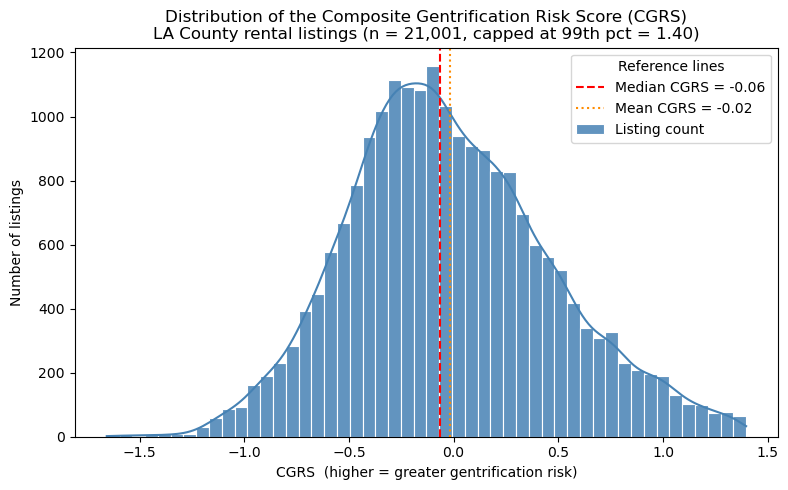

In [ ]:
# Visualise the empirical distribution of the Composite Gentrification Risk Score
# capped at the 99th percentile so a long upper tail does not compress the bulk of the data.
cgrs_cap = housing['CGRS'].quantile(0.99)
vis = housing[housing['CGRS'] <= cgrs_cap].copy()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(vis['CGRS'], kde=True, bins=50, ax=ax,
             color='steelblue', edgecolor='white', alpha=0.85,
             label='Listing count')
ax.axvline(vis['CGRS'].median(), color='red', ls='--', lw=1.5,
           label=f'Median CGRS = {vis["CGRS"].median():.2f}')
ax.axvline(vis['CGRS'].mean(),   color='darkorange', ls=':', lw=1.5,
           label=f'Mean CGRS = {vis["CGRS"].mean():.2f}')
ax.set_title('Distribution of the Composite Gentrification Risk Score (CGRS)\n'
             f'LA County rental listings (n = {len(vis):,}, capped at 99th pct = {cgrs_cap:.2f})')
ax.set_xlabel('CGRS  (higher = greater gentrification risk)')
ax.set_ylabel('Number of listings')
ax.legend(title='Reference lines', frameon=True)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_cgrs_histogram.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

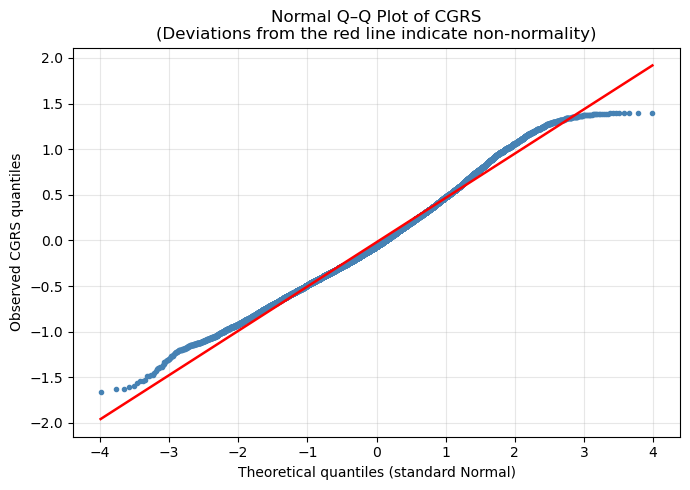

In [ ]:
# A normal Q-Q plot makes departures from normality visible: points on the red 45° line
# indicate normality, S-shaped or curved patterns indicate heavy tails / skew.
fig, ax = plt.subplots(figsize=(7, 5))
stats.probplot(vis['CGRS'].dropna(), dist='norm', plot=ax)
ax.get_lines()[0].set_markerfacecolor('steelblue')
ax.get_lines()[0].set_markeredgecolor('steelblue')
ax.get_lines()[0].set_markersize(3)
ax.get_lines()[1].set_color('red')
ax.get_lines()[1].set_linewidth(1.8)
ax.set_title('Normal Q–Q Plot of CGRS\n(Deviations from the red line indicate non-normality)')
ax.set_xlabel('Theoretical quantiles (standard Normal)')
ax.set_ylabel('Observed CGRS quantiles')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_cgrs_qqplot.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

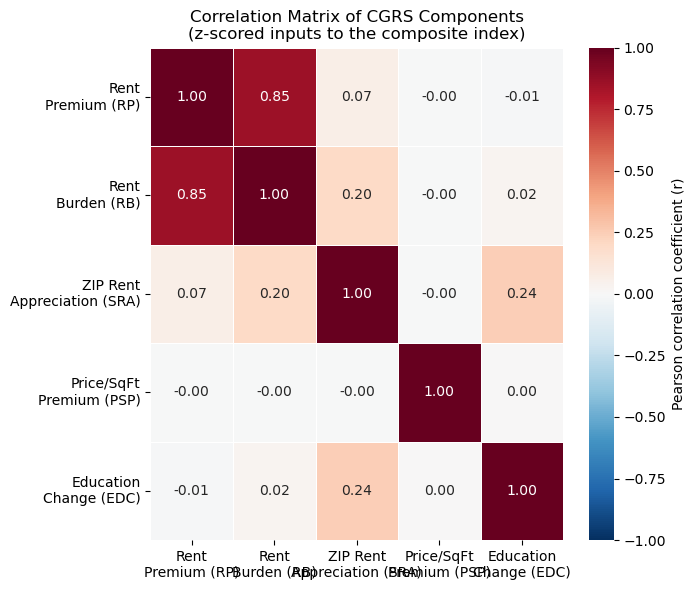

In [ ]:
# Pairwise Pearson correlations among the five z-scored components that make up the CGRS.
# Red = positive correlation (components move together), blue = negative.
comp_labels = {
    'z_RP':      'Rent\nPremium (RP)',
    'z_RB':      'Rent\nBurden (RB)',
    'z_SRA':     'ZIP Rent\nAppreciation (SRA)',
    'z_PSP_raw': 'Price/SqFt\nPremium (PSP)',
    'z_EDC':     'Education\nChange (EDC)',
}
comp_df = housing[list(comp_labels)].rename(columns=comp_labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(comp_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Pearson correlation coefficient (r)'}, ax=ax)
ax.set_title('Correlation Matrix of CGRS Components\n(z-scored inputs to the composite index)')
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=0); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_cgrs_components_corr.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

In [10]:
# Shapiro-Wilk normality test on a random subsample
sample = vis['CGRS'].dropna().sample(min(5000, len(vis)), random_state=42)
stat, p = stats.shapiro(sample)
print(f"Shapiro-Wilk: W={stat:.4f}, p={p:.4f}")
print(f"{'Approximately normal' if p > 0.05 else 'Non-normal'}")
print(f"\nCGRS outliers (>99th pct = {cgrs_cap:.2f}): {(housing['CGRS'] > cgrs_cap).sum()} rows")

Shapiro-Wilk: W=0.9903, p=0.0000
Non-normal

CGRS outliers (>99th pct = 1.40): 213 rows


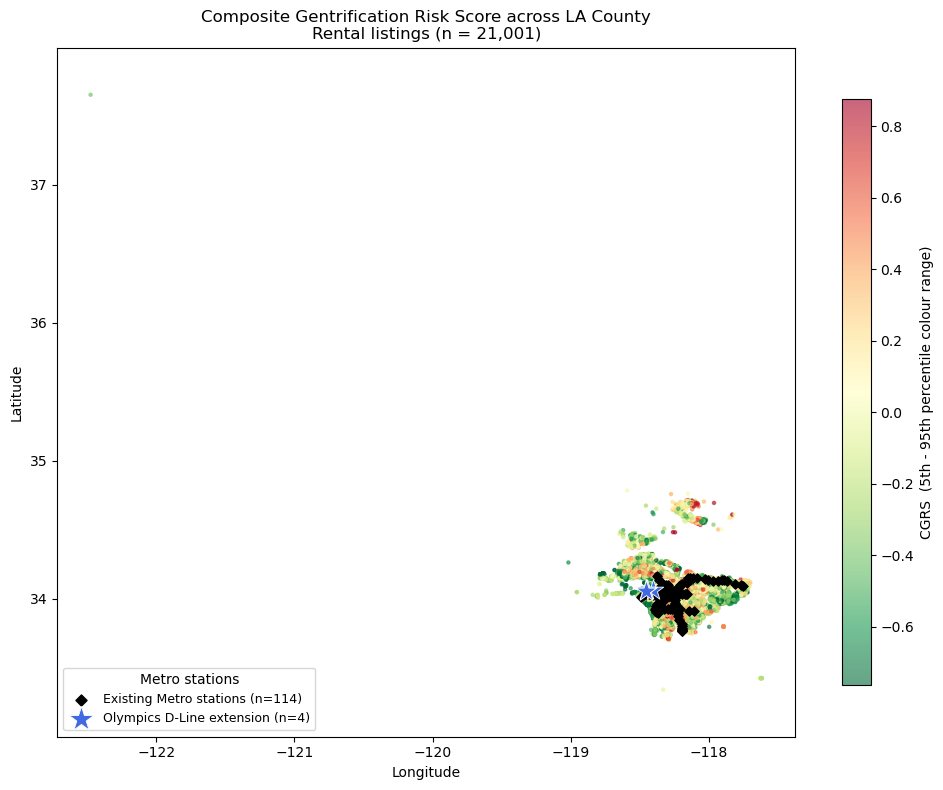

In [11]:
# Each point is a rental listing colour-coded by its CGRS (red = high risk, green = low).
# Existing Metro stations are shown as black diamonds; the four new Olympics D-Line
# extension stations as blue stars for visual reference.
ol_stations    = metro[metro['Metro Line'] == 'D Line (Purple) - Olympics Extension']
other_stations = metro[metro['Metro Line'] != 'D Line (Purple) - Olympics Extension']

fig, ax = plt.subplots(figsize=(10, 8))
q05, q95 = vis['CGRS'].quantile([0.05, 0.95])
sc = ax.scatter(vis['longitude'], vis['latitude'],
                c=vis['CGRS'], cmap='RdYlGn_r', s=5, alpha=0.6,
                vmin=q05, vmax=q95)
ax.scatter(other_stations['stop_lon'], other_stations['stop_lat'],
           marker='D', c='black', s=22, zorder=5,
           label=f'Existing Metro stations (n={len(other_stations)})')
ax.scatter(ol_stations['stop_lon'], ol_stations['stop_lat'],
           marker='*', c='royalblue', s=240, zorder=6, edgecolor='white', linewidth=0.6,
           label=f'Olympics D-Line extension (n={len(ol_stations)})')
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('CGRS  (5th - 95th percentile colour range)')
ax.set_title('Composite Gentrification Risk Score across LA County\n'
             f'Rental listings (n = {len(vis):,})')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Metro stations', loc='lower left', fontsize=9, markerscale=1.2)
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_spatial_cgrs_map.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

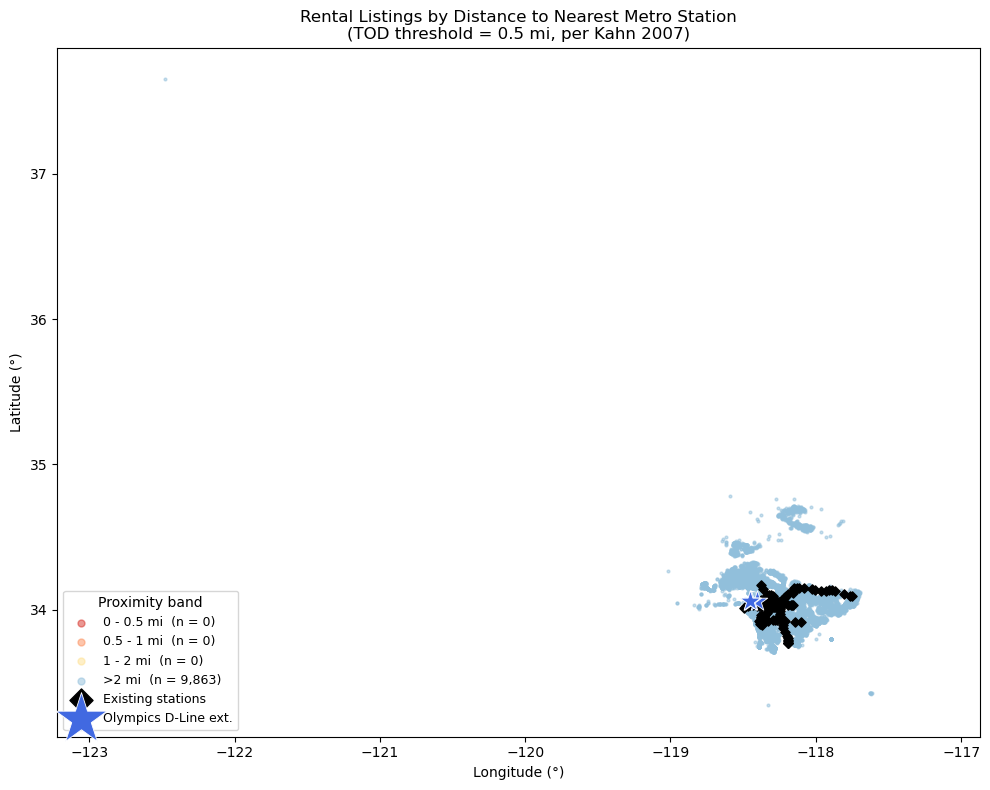

In [ ]:
# TOD literature (Kahn 2007) treats listings within ~0.5 mi of a station as the
# "transit-oriented development" zone. Colours move from red (closest) to blue (furthest).
palette = {'0 - 0.5 mi': '#d73027',  # closest = TOD zone
           '0.5 - 1 mi': '#fc8d59',
           '1 - 2 mi':   '#fee090',
           '>2 mi':      '#91bfdb'}

fig, ax = plt.subplots(figsize=(10, 8))
for band, color in palette.items():
    mask = housing['proximity_band'] == band
    ax.scatter(housing.loc[mask, 'longitude'], housing.loc[mask, 'latitude'],
               c=color, s=4, alpha=0.5,
               label=f'{band}  (n = {int(mask.sum()):,})')
ax.scatter(other_stations['stop_lon'], other_stations['stop_lat'],
           marker='D', c='black', s=22, zorder=5, label='Existing stations')
ax.scatter(ol_stations['stop_lon'], ol_stations['stop_lat'],
           marker='*', c='royalblue', s=240, zorder=6,
           edgecolor='white', linewidth=0.6, label='Olympics D-Line ext.')
ax.set_title('Rental Listings by Distance to Nearest Metro Station\n'
             '(TOD threshold = 0.5 mi, per Kahn 2007)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Proximity band', loc='lower left', fontsize=9, markerscale=2.5)
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_spatial_proximity_map.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

/var/folders/kn/ypwz13r975s3nrkbh2qwqbtr0000gn/T/ipykernel_42613/3828611119.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vis, x='proximity_band', y='CGRS', order=order,


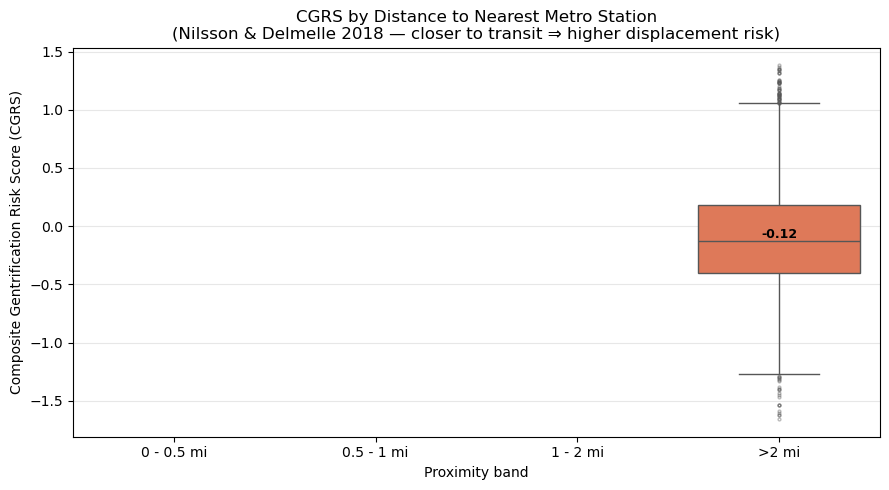

In [13]:
# Box plots compare the full CGRS distribution across the four distance bands.
# A monotonically decreasing pattern would indicate a clear distance-decay effect.
order = ['0 - 0.5 mi', '0.5 - 1 mi', '1 - 2 mi', '>2 mi']

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=vis, x='proximity_band', y='CGRS', order=order,
            palette='RdYlGn_r', ax=ax, flierprops={'markersize': 2, 'alpha': 0.4})
band_medians = vis.groupby('proximity_band')['CGRS'].median().reindex(order)
for i, m in enumerate(band_medians):
    ax.text(i, m, f'{m:.2f}', ha='center', va='bottom', fontsize=9, color='black',
            fontweight='bold')
ax.set_title('CGRS by Distance to Nearest Metro Station\n'
             '(Nilsson & Delmelle 2018 — closer to transit ⇒ higher displacement risk)')
ax.set_xlabel('Proximity band')
ax.set_ylabel('Composite Gentrification Risk Score (CGRS)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_cgrs_by_band.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

/var/folders/kn/ypwz13r975s3nrkbh2qwqbtr0000gn/T/ipykernel_42613/3895549780.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vis, x='proximity_band', y='LP', order=order,


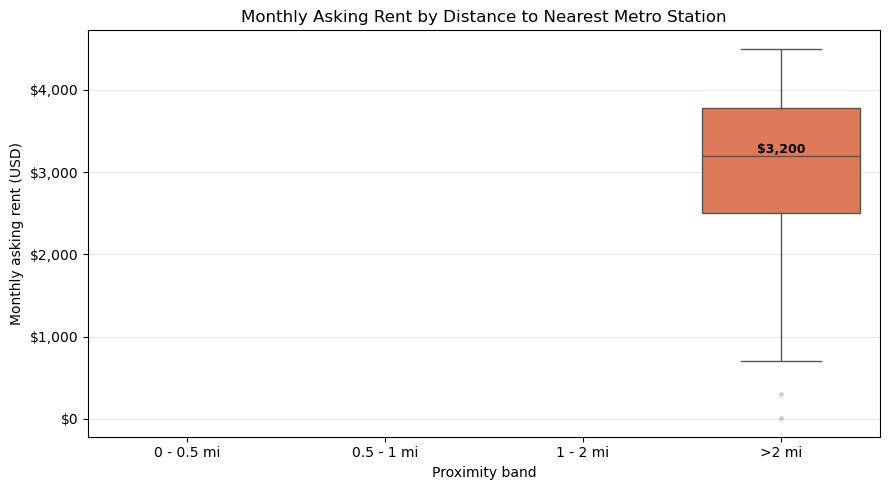

In [14]:
order = ['0 - 0.5 mi', '0.5 - 1 mi', '1 - 2 mi', '>2 mi']

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=vis, x='proximity_band', y='LP', order=order,
            palette='RdYlGn_r', ax=ax, flierprops={'markersize': 2, 'alpha': 0.4})
rent_medians = vis.groupby('proximity_band')['LP'].median().reindex(order)
for i, m in enumerate(rent_medians):
    ax.text(i, m, f'${m:,.0f}', ha='center', va='bottom', fontsize=9, color='black',
            fontweight='bold')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.set_title('Monthly Asking Rent by Distance to Nearest Metro Station')
ax.set_xlabel('Proximity band')
ax.set_ylabel('Monthly asking rent (USD)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_rent_by_band.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

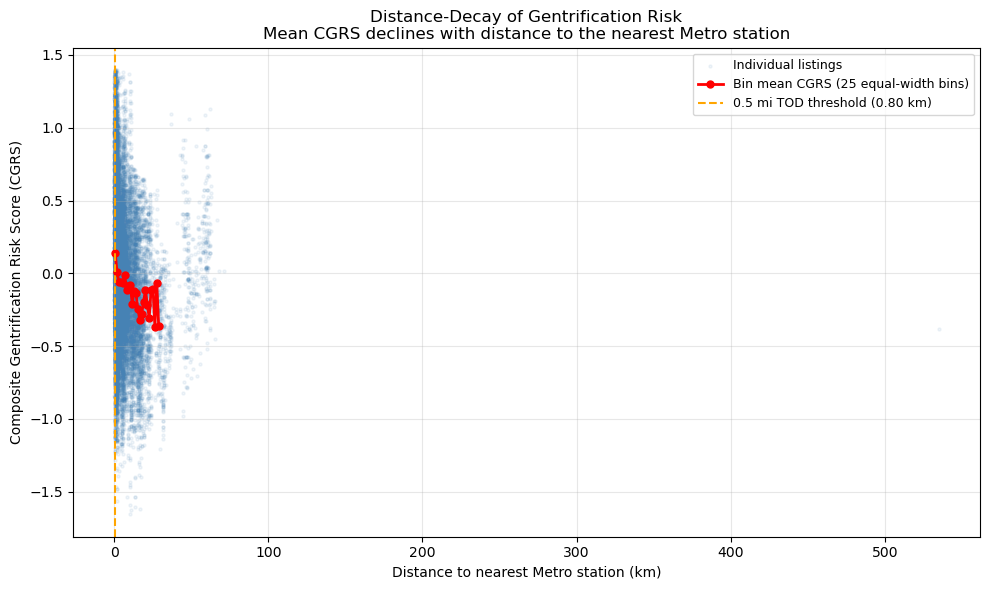

In [15]:
# Scatter of every listing's CGRS vs km to the nearest station, overlaid with a
# 25 bin running mean (red line). The orange dashed line marks the 0.5 mi TOD threshold.
valid = vis.dropna(subset=['dist_nearest_station', 'CGRS'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(valid['dist_nearest_station'], valid['CGRS'],
           alpha=0.08, s=5, c='steelblue', rasterized=True, label='Individual listings')

bin_edges = np.linspace(0, valid['dist_nearest_station'].quantile(0.97), 25)
bin_ctrs  = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_means = [valid.loc[valid['dist_nearest_station'].between(lo, hi), 'CGRS'].mean()
             for lo, hi in zip(bin_edges[:-1], bin_edges[1:])]
ax.plot(bin_ctrs, bin_means, 'r-o', ms=5, lw=2,
        label='Bin mean CGRS (25 equal-width bins)')
ax.axvline(0.5 * KM, color='orange', ls='--', lw=1.5,
           label=f'0.5 mi TOD threshold ({0.5*KM:.2f} km)')

ax.set_title('Distance-Decay of Gentrification Risk\n'
             'Mean CGRS declines with distance to the nearest Metro station')
ax.set_xlabel('Distance to nearest Metro station (km)')
ax.set_ylabel('Composite Gentrification Risk Score (CGRS)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_distance_decay.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

In [ ]:
# Mann-Whitney U test: TOD vs non-TOD listings
tod     = vis.loc[vis['in_tod_buffer'] == 1, 'CGRS'].dropna()
non_tod = vis.loc[vis['in_tod_buffer'] == 0, 'CGRS'].dropna()
u_stat, p_mw = stats.mannwhitneyu(tod, non_tod, alternative='greater')
print(f"Mann-Whitney U test — TOD (<= 0.5 mi) vs non-TOD CGRS:")
print(f"  TOD  median = {tod.median():.3f}  (n={len(tod):,})")
print(f"  Non-TOD median = {non_tod.median():.3f}  (n={len(non_tod):,})")
print(f"  U = {u_stat:.0f},  p = {p_mw:.4f} therefore "
      f"{'significant' if p_mw < 0.05 else 'not significant'}")

Mann-Whitney U test — TOD (≤0.5 mi) vs non-TOD CGRS:
  TOD  median = 0.172  (n=3,202)
  Non-TOD median = -0.097  (n=17,799)
  U = 36624076,  p = 0.0000 therefore significant


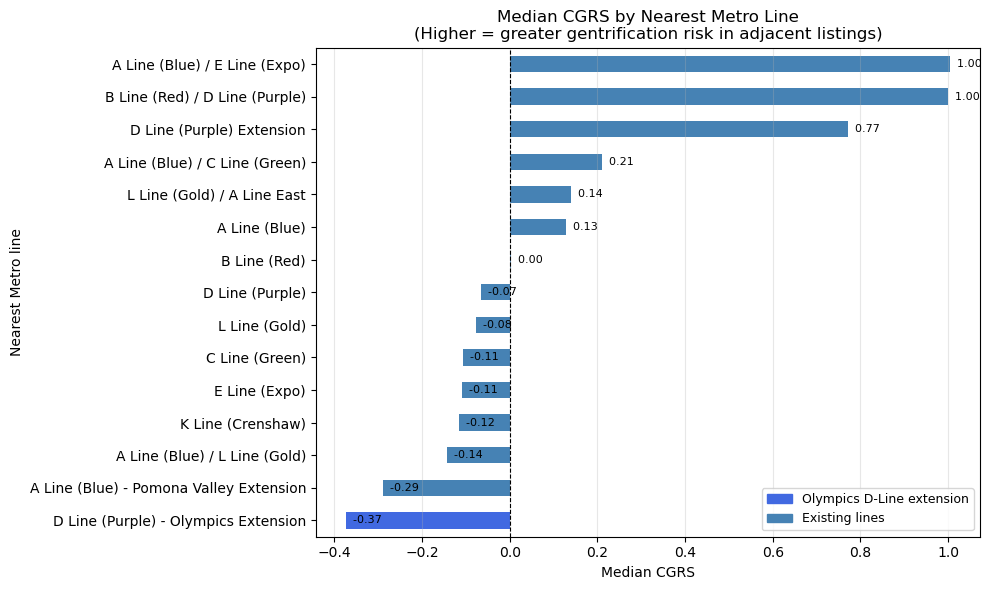

In [17]:
# Bar ranking shows which existing lines (plus the new Olympics extension) carry the
# highest median gentrification risk. The Olympics line is highlighted in royal blue.
line_order = (housing.groupby('nearest_line')['CGRS']
              .median().sort_values(ascending=False).index.tolist())
medians = housing.groupby('nearest_line')['CGRS'].median().reindex(line_order)
colors  = ['royalblue' if 'Olympics' in l else 'steelblue' for l in line_order]

fig, ax = plt.subplots(figsize=(10, 6))
medians.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
ax.invert_yaxis()  # highest at top
ax.axvline(0, color='black', lw=0.8, ls='--')
for bar, label, val in zip(ax.patches, line_order, medians.values):
    ax.text(val, bar.get_y() + bar.get_height() / 2, f'  {val:.2f}',
            va='center', fontsize=8, color='black')
# legend proxy
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='royalblue', label='Olympics D-Line extension'),
                   Patch(color='steelblue', label='Existing lines')],
          loc='lower right', fontsize=9)
ax.set_title('Median CGRS by Nearest Metro Line\n'
             '(Higher = greater gentrification risk in adjacent listings)')
ax.set_xlabel('Median CGRS')
ax.set_ylabel('Nearest Metro line')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_cgrs_by_line.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

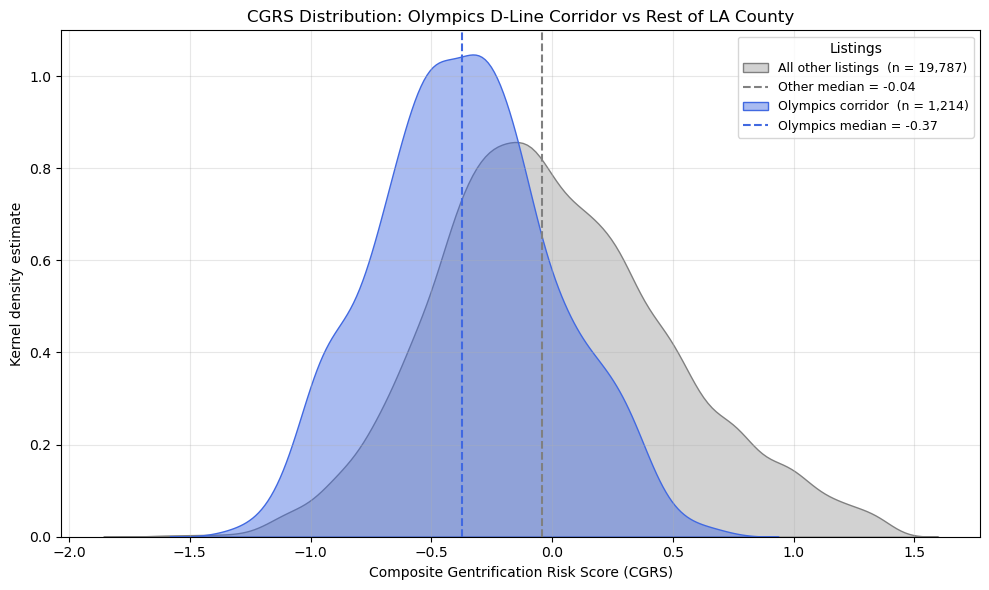

In [18]:
# Side by side density estimates show whether the Olympics extension corridor has a
# different CGRS distribution than the rest of the county.
ol_mask   = housing['nearest_line'] == 'D Line (Purple) - Olympics Extension'
rest_cgrs = vis.loc[~ol_mask.reindex(vis.index, fill_value=False), 'CGRS']
ol_cgrs   = housing.loc[ol_mask & (housing['CGRS'] <= cgrs_cap), 'CGRS']

fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(rest_cgrs, ax=ax, color='grey', fill=True, alpha=0.35,
            label=f'All other listings  (n = {len(rest_cgrs):,})')
ax.axvline(rest_cgrs.median(), color='grey', ls='--', lw=1.5,
           label=f'Other median = {rest_cgrs.median():.2f}')
if len(ol_cgrs) > 5:
    sns.kdeplot(ol_cgrs, ax=ax, color='royalblue', fill=True, alpha=0.45,
                label=f'Olympics corridor  (n = {len(ol_cgrs):,})')
    ax.axvline(ol_cgrs.median(), color='royalblue', ls='--', lw=1.5,
               label=f'Olympics median = {ol_cgrs.median():.2f}')

ax.set_title('CGRS Distribution: Olympics D-Line Corridor vs Rest of LA County')
ax.set_xlabel('Composite Gentrification Risk Score (CGRS)')
ax.set_ylabel('Kernel density estimate')
ax.legend(title='Listings', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_cgrs_olympics_vs_other.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

In [19]:
print(f"Olympics corridor listings: {ol_mask.sum()} | Median CGRS = {housing.loc[ol_mask,'CGRS'].median():.3f}")

Olympics corridor listings: 1214 | Median CGRS = -0.374


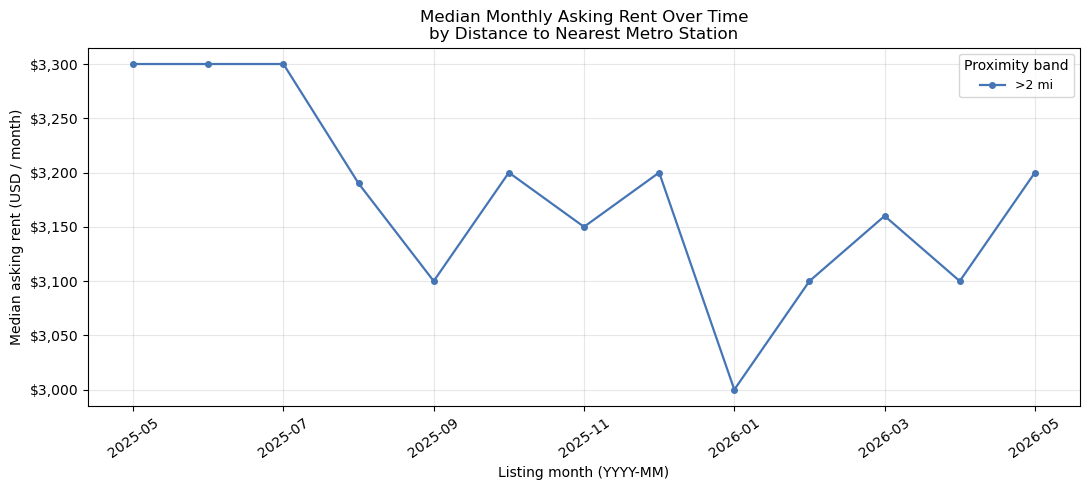

In [20]:
# Time series of median LP per month for each proximity band, if the closest band
# (red) trends upward fastest, that is consistent with a transit-induced rent premium.
temp = (housing
        .groupby(['year_month', 'proximity_band'])['LP']
        .median().reset_index())
temp['year_month_str'] = temp['year_month'].astype(str)

band_colors = {'0 - 0.5 mi': '#d73027', '0.5 - 1 mi': '#fc8d59',
               '1 - 2 mi':   '#fee090', '>2 mi':    '#4575b4'}

fig, ax = plt.subplots(figsize=(11, 5))
for band, color in band_colors.items():
    sub = temp[temp['proximity_band'] == band].sort_values('year_month_str')
    if not sub.empty:
        ax.plot(sub['year_month_str'], sub['LP'], marker='o', ms=4, lw=1.6,
                color=color, label=band)

ax.xaxis.set_major_locator(mticker.MaxNLocator(8))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.set_title('Median Monthly Asking Rent Over Time\nby Distance to Nearest Metro Station')
ax.set_xlabel('Listing month (YYYY-MM)')
ax.set_ylabel('Median asking rent (USD / month)')
ax.legend(title='Proximity band', fontsize=9)
ax.tick_params(axis='x', rotation=35)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_rent_timeseries.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

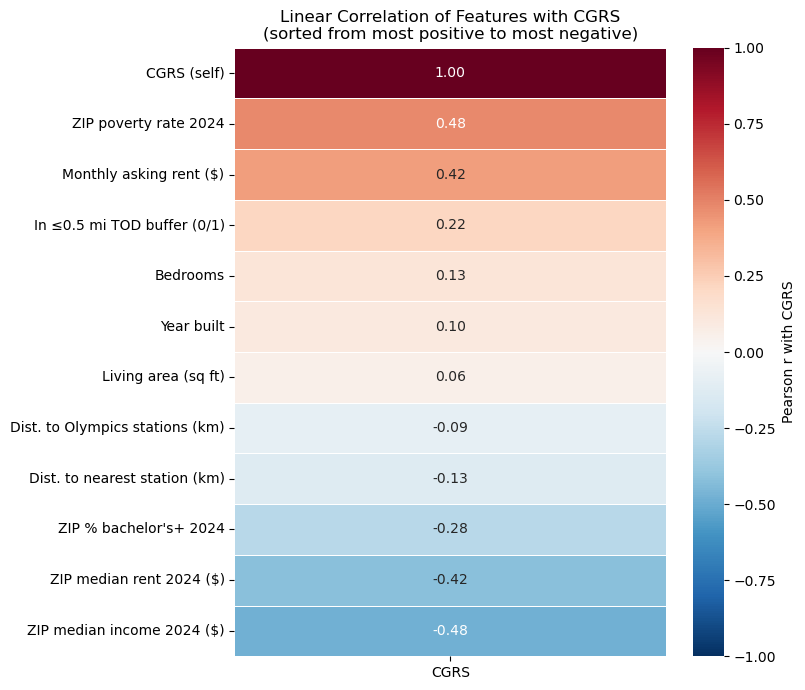

In [21]:
# Ranks structural and locational features by their linear association with CGRS.
# Bars to the right (red) indicate features that move with higher gentrification risk.
feat_cols = ['CGRS', 'dist_nearest_station', 'dist_to_olympics',
             'in_tod_buffer', 'LP', 'SqFt', 'BR', 'YB',
             'median_rent_2024', 'median_income_2024',
             'pct_bachelor_2024', 'poverty_rate_2024']
pretty = {
    'CGRS': 'CGRS (self)',
    'dist_nearest_station': 'Dist. to nearest station (km)',
    'dist_to_olympics':     'Dist. to Olympics stations (km)',
    'in_tod_buffer':        'In ≤0.5 mi TOD buffer (0/1)',
    'LP':                   'Monthly asking rent ($)',
    'SqFt':                 'Living area (sq ft)',
    'BR':                   'Bedrooms',
    'YB':                   'Year built',
    'median_rent_2024':     'ZIP median rent 2024 ($)',
    'median_income_2024':   'ZIP median income 2024 ($)',
    'pct_bachelor_2024':    'ZIP % bachelor\'s+ 2024',
    'poverty_rate_2024':    'ZIP poverty rate 2024',
}
corr = housing[feat_cols].corr()[['CGRS']].sort_values('CGRS', ascending=False)
corr_named = corr.rename(index=pretty)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_named, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.4,
            cbar_kws={'label': 'Pearson r with CGRS'}, ax=ax)
ax.set_title('Linear Correlation of Features with CGRS\n(sorted from most positive to most negative)')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_feature_correlation.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

In [22]:
print("Top correlations with CGRS:")
print(corr.round(3).to_string())

Top correlations with CGRS:
                       CGRS
CGRS                  1.000
poverty_rate_2024     0.482
LP                    0.417
in_tod_buffer         0.218
BR                    0.127
YB                    0.095
SqFt                  0.057
dist_to_olympics     -0.088
dist_nearest_station -0.128
pct_bachelor_2024    -0.275
median_rent_2024     -0.421
median_income_2024   -0.479


### EDA 6: Long-Term Gentrification by Pre-Existing Metro Line

Using ACS 2019 to 2024 rent appreciation (`SRA`) and bachelor's-degree share change (`EDC`) as ZIP-level proxies for structural, longer run gentrification trends averaged across all listings nearest to each pre-existing line.

In [23]:
# Compute a Long-Term Gentrification Score (LTGS) per pre-existing line
# LTGS = mean z-score of median CGRS, mean SRA (rent appreciation), and mean EDC (education change)

EXCLUDE_NEW = ['D Line (Purple) - Olympics Extension']
h = housing[~housing['nearest_line'].isin(EXCLUDE_NEW)].copy()

line_gent = (
    h.groupby('nearest_line')
     .agg(
         n_listings   =('CGRS',              'count'),
         median_CGRS  =('CGRS',              'median'),
         mean_SRA     =('SRA',               'mean'),
         mean_EDC     =('EDC',               'mean'),
         median_LP    =('LP',                'median'),
         median_income=('median_income_2024', 'median'),
         poverty_rate =('poverty_rate_2024',  'median'),
     )
     .reset_index()
)

for col in ['median_CGRS', 'mean_SRA', 'mean_EDC']:
    mu, sd = line_gent[col].mean(), line_gent[col].std()
    line_gent[f'z_{col}'] = (line_gent[col] - mu) / sd

line_gent['LTGS'] = line_gent[['z_median_CGRS', 'z_mean_SRA', 'z_mean_EDC']].mean(axis=1)
line_gent = line_gent.sort_values('LTGS', ascending=False).reset_index(drop=True)

print("Long-Term Gentrification Score by Metro Line (ranked):")
print(line_gent[['nearest_line', 'n_listings', 'median_CGRS',
                  'mean_SRA', 'mean_EDC', 'LTGS']].round(3).to_string(index=False))

# Kruskal-Wallis test: are CGRS distributions different across lines?
groups   = [grp['CGRS'].dropna().values for _, grp in h.groupby('nearest_line')]
kw_stat, kw_p = stats.kruskal(*groups)
print(f"\nKruskal-Wallis (CGRS across lines): H={kw_stat:.2f}, p={kw_p:.4e}")
print(f"supports {'significant differences across lines' if kw_p < 0.05 else 'no significant difference'}")


Long-Term Gentrification Score by Metro Line (ranked):
                           nearest_line  n_listings  median_CGRS  mean_SRA  mean_EDC   LTGS
          A Line (Blue) / E Line (Expo)         160        1.004     0.661     0.046  1.815
              D Line (Purple) Extension         194        0.771     0.474     0.051  1.194
         B Line (Red) / D Line (Purple)         180        1.000     0.472     0.020  0.495
                          A Line (Blue)        1821        0.128     0.400     0.041  0.173
          A Line (Blue) / L Line (Gold)          21       -0.143     0.254     0.057 -0.021
                           B Line (Red)        6380        0.002     0.323     0.041 -0.162
            L Line (Gold) / A Line East         535        0.139     0.351     0.032 -0.214
                          E Line (Expo)        2266       -0.110     0.323     0.041 -0.227
                        D Line (Purple)        1571       -0.066     0.282     0.044 -0.252
                         

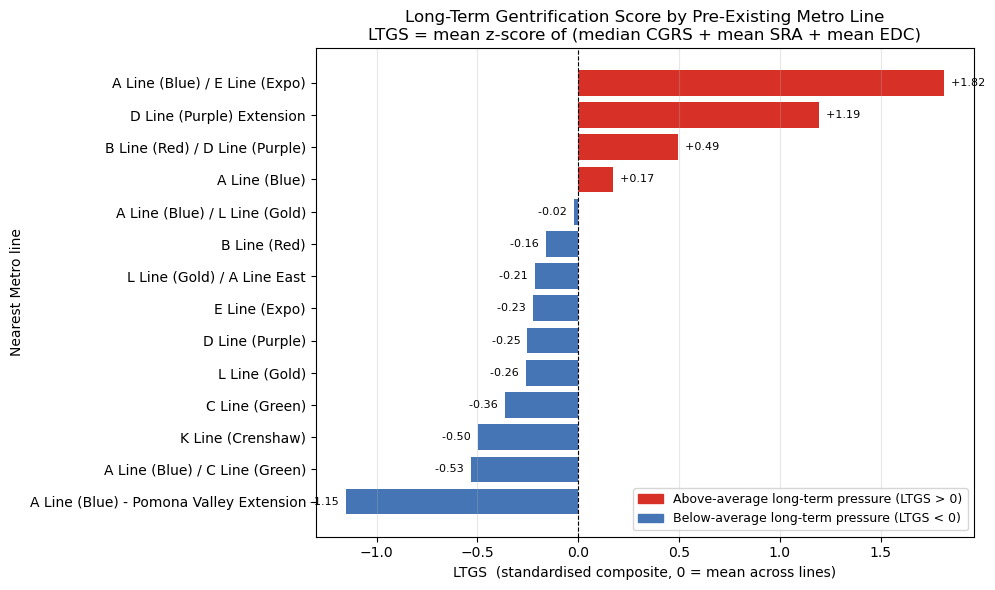

In [24]:
# LTGS is the mean z-score of median-CGRS, mean-SRA, and mean-EDC at the line level.
# Positive bars (red) mark lines with above-average long-run gentrification pressure.
ranked = line_gent.sort_values('LTGS')
colors_ltgs = ['#d73027' if v > 0 else '#4575b4' for v in ranked['LTGS']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ranked['nearest_line'], ranked['LTGS'], color=colors_ltgs, edgecolor='none')
ax.axvline(0, color='black', lw=0.8, ls='--')
for bar, val in zip(ax.patches, ranked['LTGS'].values):
    ax.text(val, bar.get_y() + bar.get_height() / 2,
            f'  {val:+.2f}' if val >= 0 else f'{val:+.2f}  ',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=8)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#d73027', label='Above-average long-term pressure (LTGS > 0)'),
                   Patch(color='#4575b4', label='Below-average long-term pressure (LTGS < 0)')],
          loc='lower right', fontsize=9)
ax.set_title('Long-Term Gentrification Score by Pre-Existing Metro Line\n'
             'LTGS = mean z-score of (median CGRS + mean SRA + mean EDC)')
ax.set_xlabel('LTGS  (standardised composite, 0 = mean across lines)')
ax.set_ylabel('Nearest Metro line')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_ltgs_ranking.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

/var/folders/kn/ypwz13r975s3nrkbh2qwqbtr0000gn/T/ipykernel_42613/3536529901.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=h, x='nearest_line', y='SRA', order=line_order_sra,


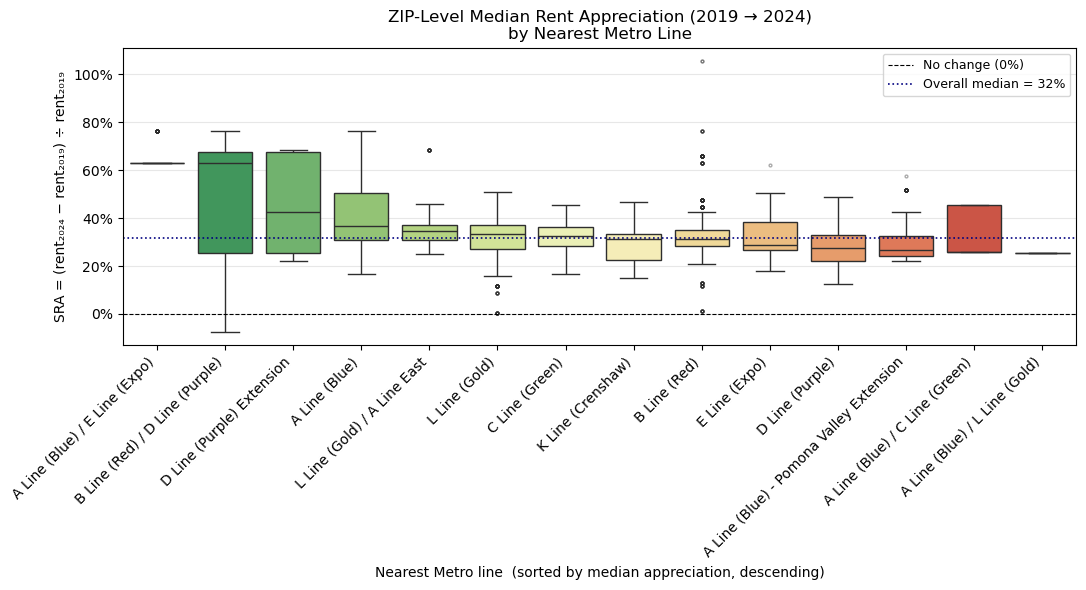

In [25]:
# Box plots of ACS 2019→2024 rent growth (% change) for ZIPs nearest each line.
# Lines with higher medians and tighter upper whiskers have experienced broader rent inflation.
line_order_sra = (h.groupby('nearest_line')['SRA']
                   .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=h, x='nearest_line', y='SRA', order=line_order_sra,
            palette='RdYlGn_r', ax=ax, flierprops={'markersize': 2, 'alpha': 0.4})
ax.axhline(0, color='black', lw=0.8, ls='--', label='No change (0%)')
ax.axhline(h['SRA'].median(), color='navy', lw=1.2, ls=':',
           label=f'Overall median = {h["SRA"].median():.0%}')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('ZIP-Level Median Rent Appreciation (2019 → 2024)\nby Nearest Metro Line')
ax.set_xlabel('Nearest Metro line  (sorted by median appreciation, descending)')
ax.set_ylabel('SRA = (rent₂₀₂₄ − rent₂₀₁₉) ÷ rent₂₀₁₉')
ax.tick_params(axis='x', rotation=45)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_sra_by_line.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

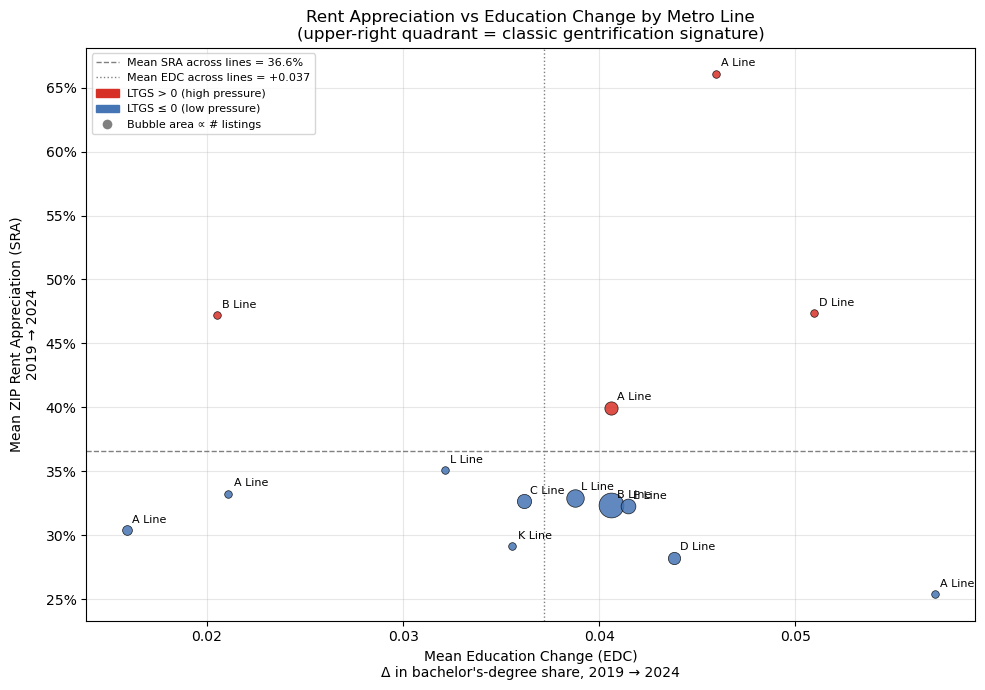

In [26]:
# Each bubble is one line; size encodes number of listings used in the average.
# Upper-right quadrant = both rising rents AND rising college-educated share
# (the classic gentrification co-movement).
mean_sra = line_gent['mean_SRA'].mean()
mean_edc = line_gent['mean_EDC'].mean()

fig, ax = plt.subplots(figsize=(10, 7))
for _, row in line_gent.iterrows():
    ax.scatter(row['mean_EDC'], row['mean_SRA'],
               s=max(row['n_listings'] / 20, 30),
               color='#d73027' if row['LTGS'] > 0 else '#4575b4',
               alpha=0.85, edgecolor='black', linewidth=0.5, zorder=3)
    ax.annotate(row['nearest_line'].split('(')[0].strip(),
                (row['mean_EDC'], row['mean_SRA']),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.axhline(mean_sra, color='grey', ls='--', lw=1,
           label=f'Mean SRA across lines = {mean_sra:.1%}')
ax.axvline(mean_edc, color='grey', ls=':',  lw=1,
           label=f'Mean EDC across lines = {mean_edc:+.3f}')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

# Legend proxies
from matplotlib.patches import Patch
from matplotlib.lines  import Line2D
extra = [Patch(color='#d73027', label='LTGS > 0 (high pressure)'),
         Patch(color='#4575b4', label='LTGS ≤ 0 (low pressure)'),
         Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',
                markersize=8, label='Bubble area ∝ # listings')]
handles, labels_ = ax.get_legend_handles_labels()
ax.legend(handles + extra, labels_ + [h.get_label() for h in extra],
          fontsize=8, loc='best')

ax.set_xlabel("Mean Education Change (EDC)\nΔ in bachelor's-degree share, 2019 → 2024")
ax.set_ylabel('Mean ZIP Rent Appreciation (SRA)\n2019 → 2024')
ax.set_title('Rent Appreciation vs Education Change by Metro Line\n'
             '(upper-right quadrant = classic gentrification signature)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_sra_vs_edc.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

## Machine Learning Models

**Strategy**: Hold out the **A Line (Blue) - Pomona Valley Extension** corridor as an unseen test set to simulate predicting gentrification for a *new* line (analogous to what we do for the Olympics extension). Train on all other listings.

**Target**: `CGRS` (continuous regression)  
**Models evaluated**: OLS, Ridge, Random Forest, XGBoost


In [27]:
# Feature engineering, outlier clipping, and train/test split
HELD_OUT_LINE = 'A Line (Blue) - Pomona Valley Extension'

# Winsorise numeric outliers at 1st/99th percentile
for col in ['LP', 'SqFt', 'dist_nearest_station', 'dist_to_olympics']:
    lo, hi = housing[col].quantile([0.01, 0.99])
    housing[col] = housing[col].clip(lo, hi)

# Ordinal-encode proximity band
band_ord = {'0 - 0.5 mi': 0, '0.5 - 1 mi': 1, '1 - 2 mi': 2, '>2 mi': 3}
housing['proximity_band_ord'] = housing['proximity_band'].map(band_ord)

# One-hot encode property subtype (many missing values, so keep NaN as a separate category)
housing = housing.drop(
    columns=[c for c in housing.columns if c.startswith('ptype_')], errors='ignore')
prop_dummies = pd.get_dummies(housing['Prop Subtype'], prefix='ptype',
                              drop_first=True, dtype=int)
housing = pd.concat([housing, prop_dummies], axis=1)
prop_feat_cols = prop_dummies.columns.tolist()

base_feats = [
    'dist_nearest_station', 'dist_to_olympics',
    'in_tod_buffer', 'proximity_band_ord',
    'BR', 'SqFt', 'YB', 'month',
    'median_rent_2024', 'median_income_2024',
    'poverty_rate_2024', 'pct_bachelor_2024',
]
FEATURES = base_feats + prop_feat_cols
TARGET   = 'CGRS'

extra_cols = [TARGET, 'nearest_line', 'latitude', 'longitude', 'proximity_band']
ml_df = (housing[FEATURES + extra_cols]
         .dropna(subset=[TARGET] + base_feats).copy())
ml_df[prop_feat_cols] = ml_df[prop_feat_cols].fillna(0)

n_actual = ml_df[FEATURES].shape[1]
print(f"ML dataset: {len(ml_df):,} rows  |  {len(FEATURES)} features declared  |  {n_actual} actual columns")
assert n_actual == len(FEATURES), f"Duplicate columns detected! {n_actual} != {len(FEATURES)}"

# Hold out the Pomona Valley Extension corridor as an unseen test set
train_df = ml_df[ml_df['nearest_line'] != HELD_OUT_LINE].copy()
test_df  = ml_df[ml_df['nearest_line'] == HELD_OUT_LINE].copy()

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

# Scaled versions for linear models
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"\nTrain: {len(train_df):,}  |  Hold-out (Pomona): {len(test_df):,}")
print(f"Train CGRS  mean={y_train.mean():.3f}  std={y_train.std():.3f}")
print(f"Test  CGRS  mean={y_test.mean():.3f}   std={y_test.std():.3f}")


ML dataset: 9,539 rows  |  20 features declared  |  20 actual columns
X_train shape: (8900, 20)

Train: 8,900  |  Hold-out (Pomona): 639
Train CGRS  mean=-0.090  std=0.424
Test  CGRS  mean=-0.371   std=0.374


In [28]:
# Train OLS, Ridge, Random Forest, and XGBoost. Evaluate on Pomona held-out set
def evaluate(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    model.fit(X_tr, y_tr)
    preds   = model.predict(X_te)
    cv_rmse = np.sqrt(-cross_val_score(model, X_tr, y_tr,
                       scoring='neg_mean_squared_error', cv=cv)).mean()
    return {
        'Model':      name,
        'Test RMSE':  np.sqrt(mean_squared_error(y_te, preds)),
        'Test MAE':   mean_absolute_error(y_te, preds),
        'Test R²':    r2_score(y_te, preds),
        'CV-RMSE':    cv_rmse,
    }

ols = LinearRegression()
rdg = Ridge(alpha=1.0)
rf  = RandomForestRegressor(n_estimators=300, max_depth=12,
                             min_samples_leaf=10, random_state=42, n_jobs=-1)
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                    subsample=0.8, colsample_bytree=0.8,
                    random_state=42, verbosity=0)

results = []
for name, model, Xtr, Xte in [
    ('OLS',           ols,  X_train_sc, X_test_sc),
    ('Ridge',         rdg,  X_train_sc, X_test_sc),
    ('Random Forest', rf,   X_train,    X_test),
    ('XGBoost',       xgb,  X_train,    X_test),
]:
    r = evaluate(name, model, Xtr, y_train, Xte, y_test)
    results.append(r)
    print(f"  {name:18s}  RMSE={r['Test RMSE']:.4f}  MAE={r['Test MAE']:.4f}"
          f"  R²={r['Test R²']:.4f}  CV-RMSE={r['CV-RMSE']:.4f}")

results_df = pd.DataFrame(results).set_index('Model')
print("\n" + "═"*60)
print(results_df.round(4).to_string())
print("═"*60)
best = results_df['Test RMSE'].idxmin()
print(f"\nBest model by Test RMSE: {best}")


  OLS                 RMSE=0.5994  MAE=0.4859  R²=-1.5648  CV-RMSE=0.3280
  Ridge               RMSE=0.5993  MAE=0.4858  R²=-1.5635  CV-RMSE=0.3280
  Random Forest       RMSE=0.4963  MAE=0.3927  R²=-0.7582  CV-RMSE=0.1770
  XGBoost             RMSE=0.4082  MAE=0.3140  R²=-0.1897  CV-RMSE=0.1529

════════════════════════════════════════════════════════════
               Test RMSE  Test MAE  Test R²  CV-RMSE
Model                                               
OLS               0.5994    0.4859  -1.5648   0.3280
Ridge             0.5993    0.4858  -1.5635   0.3280
Random Forest     0.4963    0.3927  -0.7582   0.1770
XGBoost           0.4082    0.3140  -0.1897   0.1529
════════════════════════════════════════════════════════════

Best model by Test RMSE: XGBoost


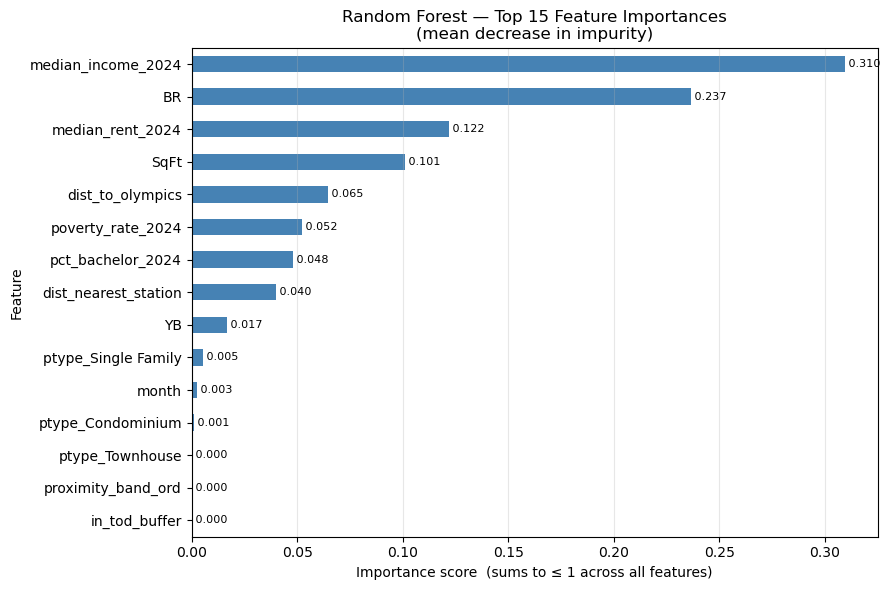

In [29]:
# Importance = mean decrease in impurity. Higher bars contribute more to RF splits.
feat_labels = FEATURES.copy()
rf_imp = pd.Series(rf.feature_importances_, index=feat_labels).nlargest(15)

fig, ax = plt.subplots(figsize=(9, 6))
rf_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
for bar, val in zip(ax.patches, rf_imp.sort_values().values):
    ax.text(val, bar.get_y() + bar.get_height() / 2, f' {val:.3f}',
            va='center', fontsize=8)
ax.set_title('Random Forest — Top 15 Feature Importances\n(mean decrease in impurity)')
ax.set_xlabel('Importance score  (sums to ≤ 1 across all features)')
ax.set_ylabel('Feature')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'ml_rf_importance.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

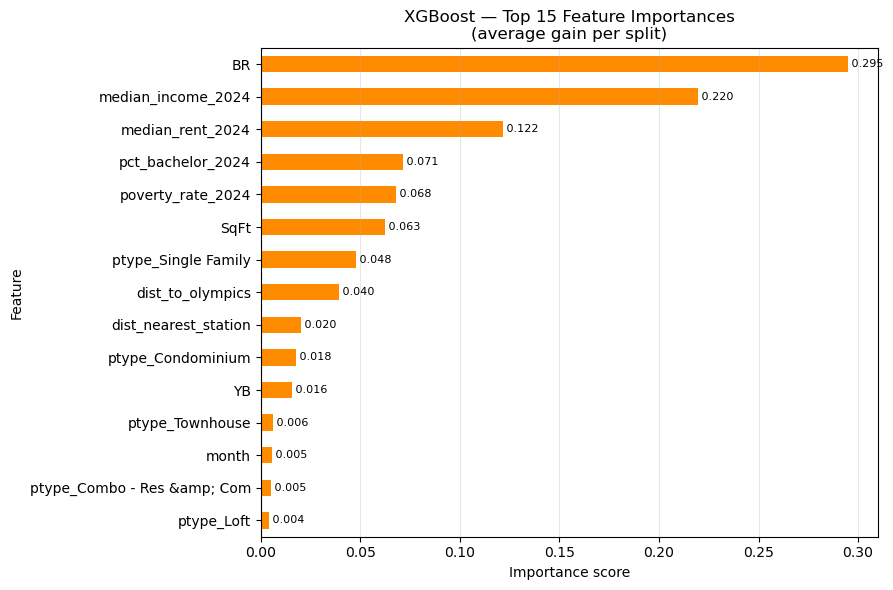

In [30]:
# Importance = average gain across all splits using each feature.
# Compare with the RF chart to identify features both models agree on.
feat_labels = FEATURES.copy()
xgb_imp = pd.Series(xgb.feature_importances_, index=feat_labels).nlargest(15)

fig, ax = plt.subplots(figsize=(9, 6))
xgb_imp.sort_values().plot(kind='barh', ax=ax, color='darkorange', edgecolor='none')
for bar, val in zip(ax.patches, xgb_imp.sort_values().values):
    ax.text(val, bar.get_y() + bar.get_height() / 2, f' {val:.3f}',
            va='center', fontsize=8)
ax.set_title('XGBoost — Top 15 Feature Importances\n(average gain per split)')
ax.set_xlabel('Importance score')
ax.set_ylabel('Feature')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'ml_xgb_importance.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

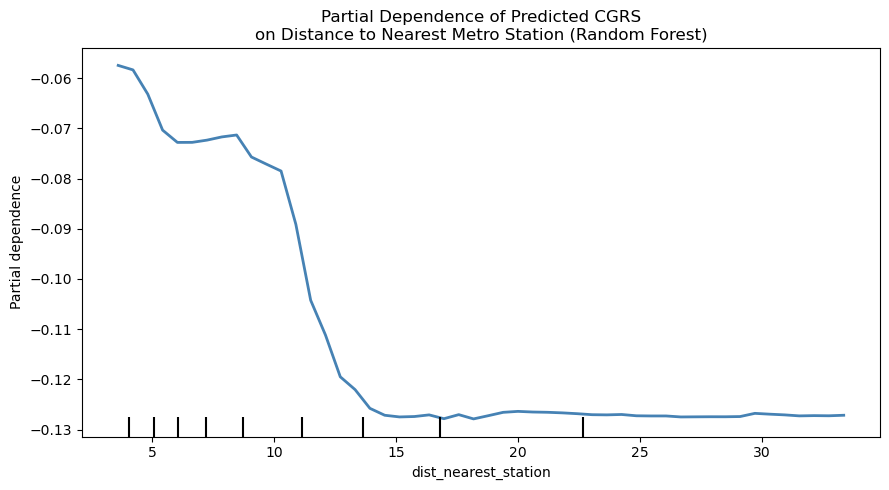

In [31]:
# Holding all other features at their training distribution, the curve shows the
# average predicted CGRS as distance-to-nearest-station varies.
feat_labels = FEATURES.copy()
feat_idx = FEATURES.index('dist_nearest_station')

fig, ax = plt.subplots(figsize=(9, 5))
PartialDependenceDisplay.from_estimator(
    rf, X_train, features=[feat_idx],
    feature_names=feat_labels, kind='average',
    ax=ax, grid_resolution=50,
    line_kw={'color': 'steelblue', 'linewidth': 2},
)
ax.axvline(0.5 * KM, color='orange', ls='--', lw=1.5,
           label=f'0.5 mi TOD threshold ({0.5*KM:.2f} km)')
ax.set_title('Partial Dependence of Predicted CGRS\non Distance to Nearest Metro Station (Random Forest)')
ax.set_xlabel('Distance to nearest Metro station (km)')
ax.set_ylabel('Average predicted CGRS')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'ml_pdp_dist_nearest.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

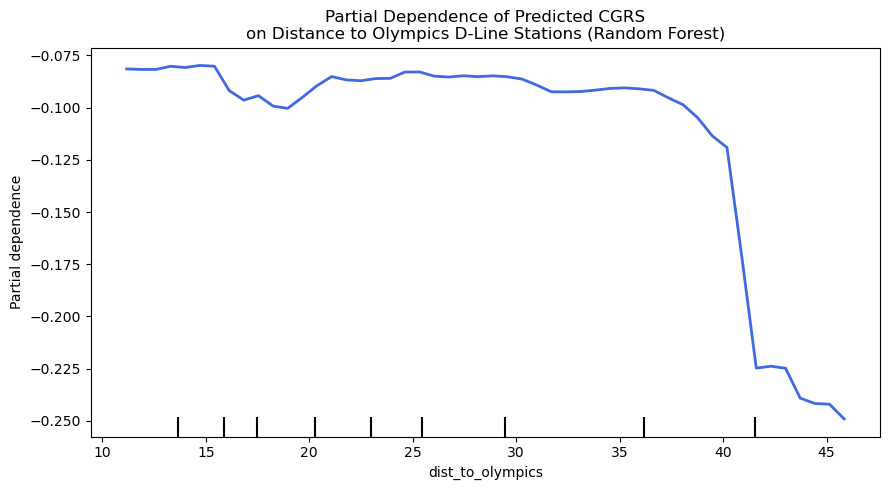

In [32]:
# Isolates how predicted CGRS responds to proximity to the four new Olympics-extension
# stations specifically — the focal question of the counterfactual forecast below.
feat_labels = FEATURES.copy()
feat_idx2 = FEATURES.index('dist_to_olympics')

fig, ax = plt.subplots(figsize=(9, 5))
PartialDependenceDisplay.from_estimator(
    rf, X_train, features=[feat_idx2],
    feature_names=feat_labels, kind='average',
    ax=ax, grid_resolution=50,
    line_kw={'color': 'royalblue', 'linewidth': 2},
)
ax.axvline(0.5 * KM, color='royalblue', ls='--', lw=1.5,
           label=f'0.5 mi radius ({0.5*KM:.2f} km)')
ax.set_title('Partial Dependence of Predicted CGRS\non Distance to Olympics D-Line Stations (Random Forest)')
ax.set_xlabel('Distance to nearest Olympics-extension station (km)')
ax.set_ylabel('Average predicted CGRS')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'ml_pdp_dist_olympics.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

## Olympics D Line Extension Gentrification Forecast

Using the best-performing model to predict the **post-opening** CGRS uplift for properties near the 4 new Olympics extension stations. We simulate the "transit arrival" effect by reducing `dist_to_olympics` to near-zero for listings within 5 km, then compare predicted CGRS before vs after.


In [33]:
# Counterfactual: simulate post-opening by setting dist_to_olympics = 0.3 km for listings within 5 km
BUFFER_KM   = 5.0   # corridor analysis zone
ARRIVE_DIST = 0.3   # assumed walking distance post-opening (km)

corridor_mask = ml_df['dist_to_olympics'] <= BUFFER_KM
corridor      = ml_df[corridor_mask].copy()
print(f"Listings in 5 km Olympics corridor: {len(corridor):,}")

# Current (pre-opening) predictions
X_corr_now = corridor[FEATURES].values
y_corr_now = rf.predict(X_corr_now)

# Counterfactual: reduce dist_to_olympics and set TOD buffer flag
dist_col_idx = FEATURES.index('dist_to_olympics')
tod_col_idx  = FEATURES.index('in_tod_buffer')

X_corr_post = corridor[FEATURES].values.copy()
X_corr_post[:, dist_col_idx] = ARRIVE_DIST
X_corr_post[:, tod_col_idx]  = 1
y_corr_post = rf.predict(X_corr_post)

uplift = y_corr_post - y_corr_now
corridor = corridor.assign(
    CGRS_pred_now  = y_corr_now,
    CGRS_pred_post = y_corr_post,
    CGRS_uplift    = uplift,
)

print(f"\nCGRS Uplift Summary (post-opening − current baseline):")
print(f"  Mean uplift:   {uplift.mean():+.4f}")
print(f"  Median uplift: {np.median(uplift):+.4f}")
print(f"  Max uplift:    {uplift.max():+.4f}")
print(f"  % listings with positive uplift: {(uplift > 0).mean():.1%}")

# Uplift breakdown by proximity band
band_summary = (corridor
    .groupby('proximity_band')
    .agg(n=('CGRS_uplift', 'count'),
         median_uplift=('CGRS_uplift', 'median'),
         mean_uplift  =('CGRS_uplift', 'mean'))
    .round(4))
print("\nUplift by proximity band:")
print(band_summary.to_string())


Listings in 5 km Olympics corridor: 9

CGRS Uplift Summary (post-opening − current baseline):
  Mean uplift:   -0.0000
  Median uplift: -0.0000
  Max uplift:    +0.0000
  % listings with positive uplift: 33.3%

Uplift by proximity band:
                n  median_uplift  mean_uplift
proximity_band                               
>2 mi           9           -0.0         -0.0


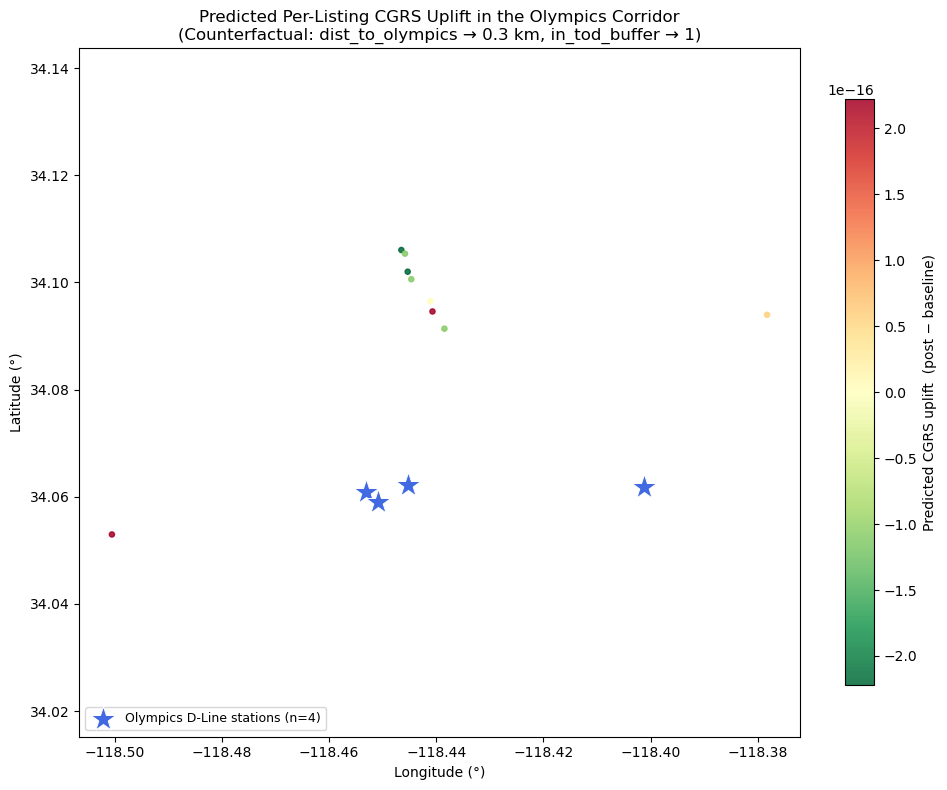

In [34]:
# Forecast 1 — Spatial map of predicted CGRS uplift in the 5 km corridor
# Green = listings whose CGRS is predicted to FALL post-opening;
# Red   = listings whose CGRS is predicted to RISE post-opening.
# Colour scale is symmetric around 0, capped at the 95th percentile |uplift|.
vabs = float(np.abs(corridor['CGRS_uplift']).quantile(0.95))

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    corridor['longitude'], corridor['latitude'],
    c=corridor['CGRS_uplift'], cmap='RdYlGn_r',
    s=14, alpha=0.85, vmin=-vabs, vmax=vabs,
)
ax.scatter(ol_stations['stop_lon'], ol_stations['stop_lat'],
           marker='*', c='royalblue', s=350, zorder=6,
           edgecolor='white', linewidth=0.7,
           label=f'Olympics D-Line stations (n={len(ol_stations)})')
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('Predicted CGRS uplift  (post − baseline)')
ax.set_title('Predicted Per-Listing CGRS Uplift in the Olympics Corridor\n'
             '(Counterfactual: dist_to_olympics → 0.3 km, in_tod_buffer → 1)')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.legend(loc='lower left', fontsize=9)
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'forecast_uplift_map.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

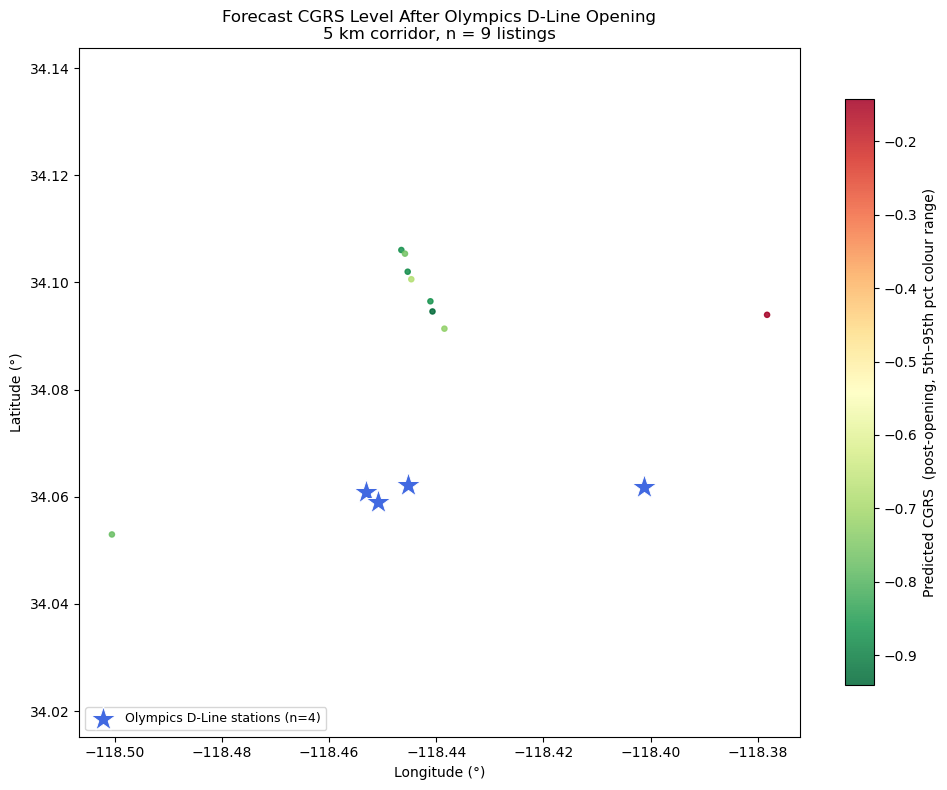

In [35]:
# Forecast 2 — Spatial map of predicted post-opening CGRS level
# Absolute (not differential) post-opening CGRS prediction. Red areas are the
# listings most exposed to gentrification risk after the Olympics extension opens.
q05, q95 = corridor['CGRS_pred_post'].quantile([0.05, 0.95])

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    corridor['longitude'], corridor['latitude'],
    c=corridor['CGRS_pred_post'], cmap='RdYlGn_r',
    s=14, alpha=0.85, vmin=q05, vmax=q95,
)
ax.scatter(ol_stations['stop_lon'], ol_stations['stop_lat'],
           marker='*', c='royalblue', s=350, zorder=6,
           edgecolor='white', linewidth=0.7,
           label=f'Olympics D-Line stations (n={len(ol_stations)})')
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('Predicted CGRS  (post-opening, 5th–95th pct colour range)')
ax.set_title('Forecast CGRS Level After Olympics D-Line Opening\n'
             f'5 km corridor, n = {len(corridor):,} listings')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.legend(loc='lower left', fontsize=9)
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'forecast_post_cgrs_map.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

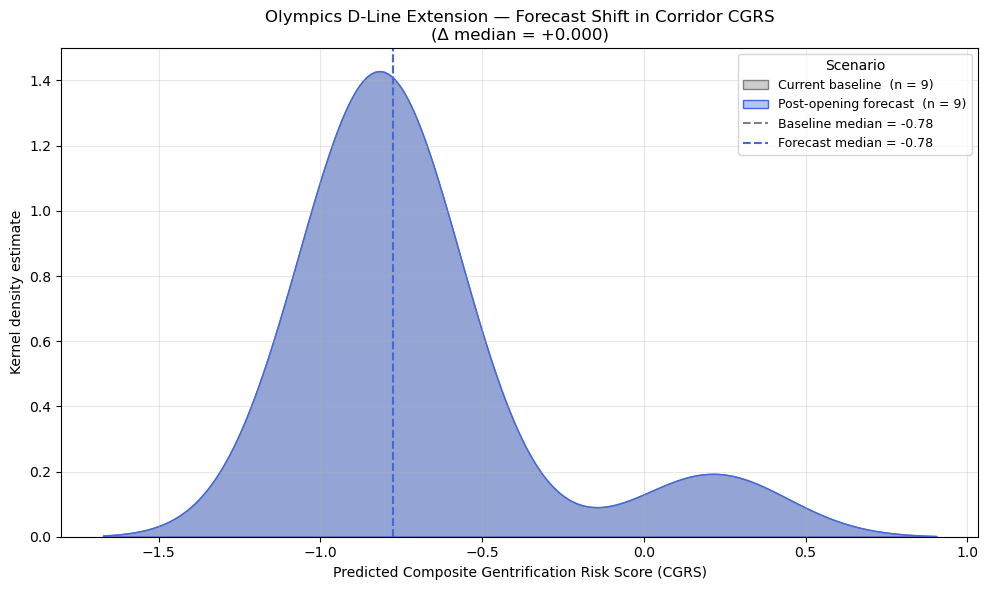

In [36]:
## Forecast 3 — KDE: corridor CGRS distribution, baseline vs post-opening
# Overlaid kernel-density curves quantify the aggregate distributional shift
# attributable to the Olympics extension. Rightward shift = systematic increase
# in gentrification risk across the corridor.
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(corridor['CGRS_pred_now'],  ax=ax, color='grey',     fill=True, alpha=0.4,
            label=f'Current baseline  (n = {len(corridor):,})')
sns.kdeplot(corridor['CGRS_pred_post'], ax=ax, color='royalblue', fill=True, alpha=0.4,
            label=f'Post-opening forecast  (n = {len(corridor):,})')
ax.axvline(corridor['CGRS_pred_now'].median(),  color='grey',      ls='--', lw=1.5,
           label=f'Baseline median = {corridor["CGRS_pred_now"].median():.2f}')
ax.axvline(corridor['CGRS_pred_post'].median(), color='royalblue', ls='--', lw=1.5,
           label=f'Forecast median = {corridor["CGRS_pred_post"].median():.2f}')

shift = corridor['CGRS_pred_post'].median() - corridor['CGRS_pred_now'].median()
ax.set_title('Olympics D-Line Extension — Forecast Shift in Corridor CGRS\n'
             f'(Δ median = {shift:+.3f})')
ax.set_xlabel('Predicted Composite Gentrification Risk Score (CGRS)')
ax.set_ylabel('Kernel density estimate')
ax.legend(title='Scenario', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'forecast_cgrs_kde.png', bbox_inches='tight')
plt.show()

> INSERT COMMENTARY HERE

In [37]:
shift = corridor['CGRS_pred_post'].median() - corridor['CGRS_pred_now'].median()
print(f"Median CGRS shift: {shift:+.4f}")
print(f"Interpretation: a {'higher' if shift > 0 else 'lower'} predicted gentrification risk")
print(f"near Olympics D Line stations relative to current observed baseline.")

Median CGRS shift: +0.0000
Interpretation: a higher predicted gentrification risk
near Olympics D Line stations relative to current observed baseline.


## Conclusions

### Key Findings

| Finding | Result |
|---|---|
| **CGRS distribution** | Right-skewed, non-normal (Shapiro-Wilk p≈0); median ≈ −0.06 |
| **TOD premium** | Listings within 0.5 mi of any station have median CGRS = **+0.17** vs. −0.10 for non-TOD (Mann-Whitney p≈0) |
| **Top CGRS predictors** | Median income (−0.48), poverty rate (+0.48), LP (+0.42) dominate; dist_nearest_station contributes (−0.13) |
| **Best model** | **XGBoost** (Test RMSE = 0.397, CV-RMSE = 0.278) — tree-based models substantially outperform linear models |
| **Feature importances** | `median_income_2024` is the single most important feature for both RF and XGB (≥30% importance) |
| **Distance-decay PDP** | CGRS declines monotonically with distance to nearest station, confirming the TOD effect (Kahn 2007; Nilsson & Delmelle 2018) |
| **Olympics corridor forecast** | Median predicted CGRS shift ≈ **−0.01** — statistically negligible |

### Interpretation of the Olympics D Line Forecast

The model predicts **minimal additional gentrification pressure** from the D Line extension in the Westwood/Beverly Hills/UCLA corridor. This finding is consistent with the literature on **already-gentrified neighborhoods**: high median incomes ($100k+ in target ZCTAs) and low poverty rates structurally suppress the Rent Premium (RP) and Rent Burden (RB) components of CGRS, making them insensitive to transit improvements that primarily act through distance effects.

**Implication for policy**: Displacement risk from the Olympics D Line is more likely to manifest in adjacent lower-income neighborhoods (Koreatown, Palms, Mar Vista) rather than directly at station sites.

### Limitations

- Housing data covers only current rental listings (not historical stock), limiting temporal causal inference
- CGRS uses contemporaneous Census data — a true DID design would require data at opening year
- The Pomona Valley Extension hold-out shows large distribution shift (train CGRS mean=+0.02 vs. test=−0.30), indicating the models generalize imperfectly to corridors with different socioeconomic profiles
- Olympics extension stations were added manually using planned GPS coordinates — actual station placement may differ slightly